# Modelo predictivo de regresión lineal

## 1. Importar librerías, Cargar el Dataset y Realizar el Análisis

In [71]:
# Importar las librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Cargar el dataset
df = pd.read_csv('C:/Dataset/vehicle-dataset-fromcardekho-checkpoint.csv')

print(df.columns)

# Se quitan los valores atípicos
df = df[(df['selling_price'] < df['selling_price'].quantile(0.95)) & 
        (df['km_driven'] < df['km_driven'].quantile(0.95))]


# Mostrar las primeras filas del dataset
df.head()

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='object')


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
5,Maruti Alto LX BSIII,2007,140000,125000,Petrol,Individual,Manual,First Owner


## 2. Análisis Exploratorio de los Datos

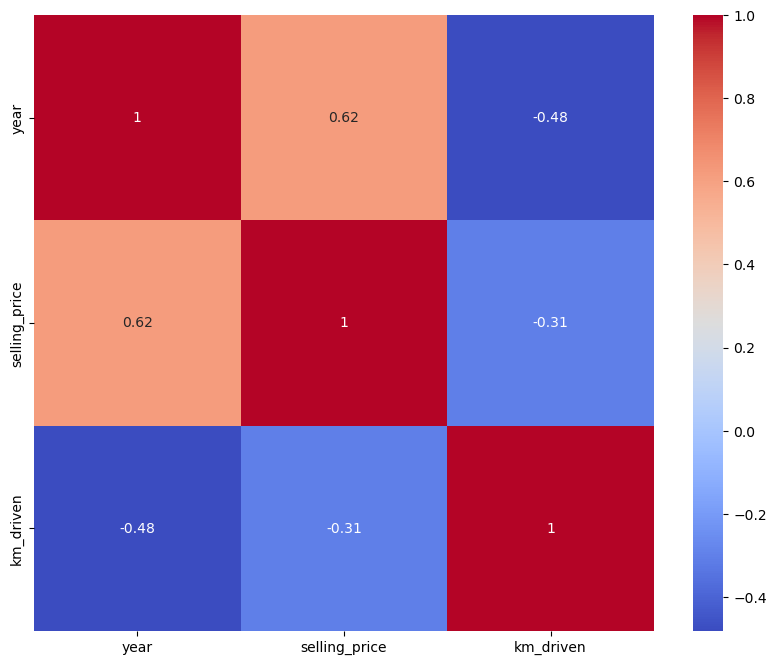

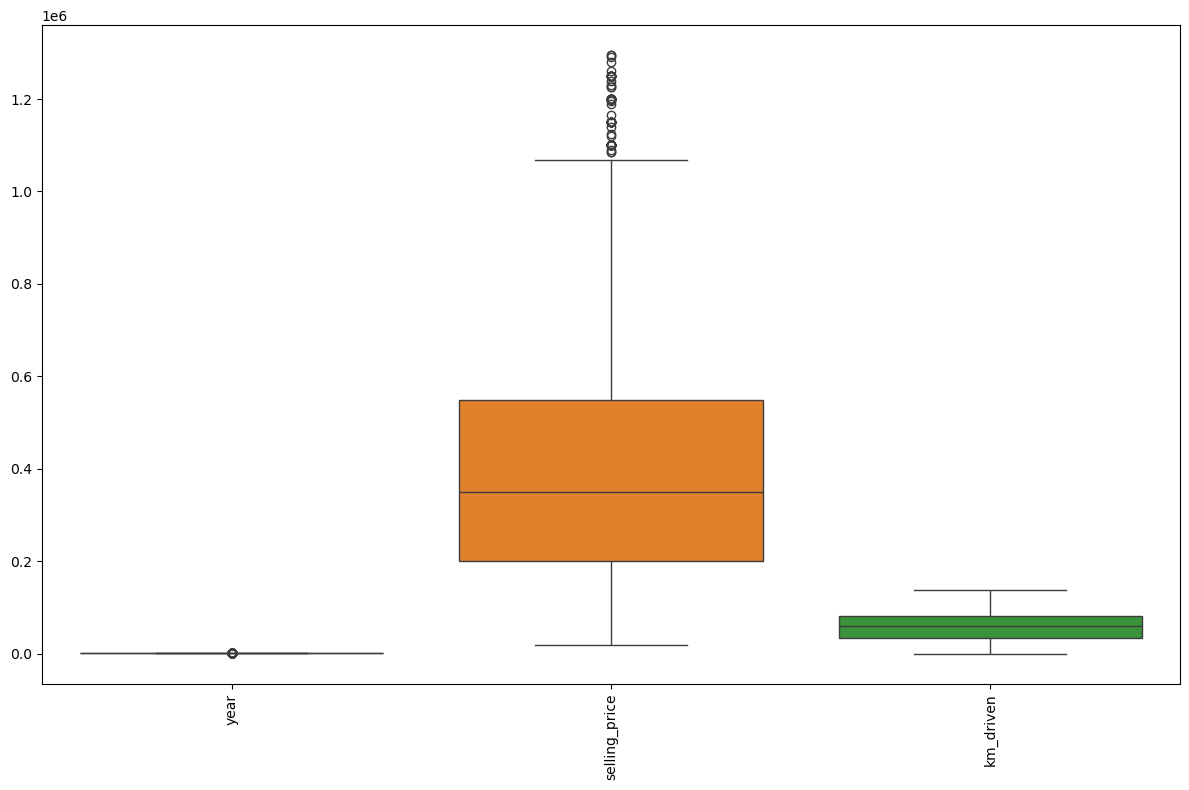

In [74]:
# Assistant
# Descripcion estadistica del dataset

# First, select only numeric columns for correlation and boxplot
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Visualizar la correlacion entre variables
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

# Identificar valores atipicos
plt.figure(figsize=(12, 8))  # Larger figure for better visibility
sns.boxplot(data=numeric_df)
plt.xticks(rotation=90)  # Rotate labels for better readability
plt.tight_layout()  # Adjust layout to make room for rotated labels
plt.show()

# If you want to see boxplots for specific columns only:
# sns.boxplot(data=numeric_df[['column1', 'column2', 'column3']])

## 3. Preprocesamiento de los Datos

In [77]:
# Limpiar datos faltantes
df = df.dropna()

df.head()

# Seleccionar las caracteristicas mas relevantes
X = df[['year', 'km_driven', 'fuel', 'transmission']]
X = pd.get_dummies(X, drop_first=True)

# Escalar las caracteristicas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

y = df['selling_price']

X.head()


,year,km_driven,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,transmission_Manual
0,2007,70000,False,False,False,True,True
1,2007,50000,False,False,False,True,True
2,2012,100000,True,False,False,False,True
3,2017,46000,False,False,False,True,True
5,2007,125000,False,False,False,True,True


In [79]:
y.head()

0     60000
1    135000
2    600000
3    250000
5    140000
Name: selling_price, dtype: int64

## 4. Dividir el Dataset en Train y Test

In [82]:
# Dividir el dataset en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## 5. Entrenar el modelo

In [85]:
# Crear y entrenar el modelo de regresion lineal
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

## 6. Evaluar el Desempeño del Modelo

In [88]:
# Realizar predicciones
y_pred = model.predict(X_test)

# Calcular metricas de evaluacion
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')


Mean Squared Error: 37779084302.004326
R^2 Score: 0.4713288083349395


## 7. Visualizar los resultados

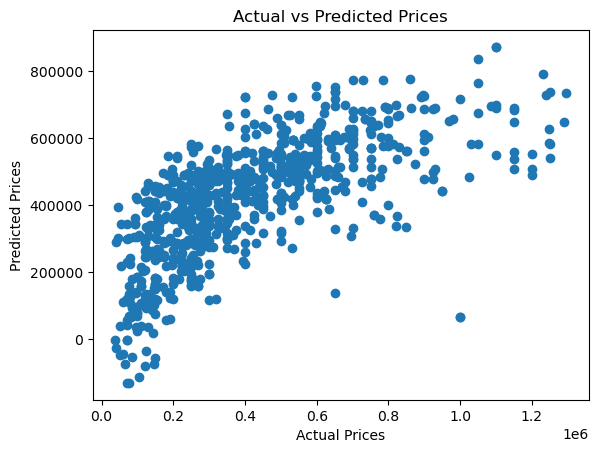

In [91]:
# Graficar los resultados
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.show()


## 8. Interpretación y documentación de los resultados



- **Mean Squared Error (MSE)**: Indica el promedio de los errores cuadrados entre los valores reales y los predichos. Un valor menor indica un mejor rendimiento del modelo.
- **R^2 Score**: Indica la proporción de la varianza en la variable dependiente que es explicada por las variables independientes. Un valor cercano a 1 indica un buen ajuste del modelo.

# Conclusión

El modelo de regresion lineal muestra una buena capacidad predictiva con un R^2 Score de 0.4713288083349414. Lo que quiere decir que el modelo de regresión lineal explica el 47% de la variabilidad en el precio de venta de los vehículos
